<!--BOOK_INFORMATION-->
<img align="left" style="padding-right:10px;" src="figures/PDSH-cover-small.png">
*This notebook contains an excerpt from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas; the content is available [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).*

*The text is released under the [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode), and code is released under the [MIT license](https://opensource.org/licenses/MIT). If you find this content useful, please consider supporting the work by [buying the book](http://shop.oreilly.com/product/0636920034919.do)!*

<!--NAVIGATION-->
< [Aggregations: Min, Max, and Everything In Between](02.04-Computation-on-arrays-aggregates.ipynb) | [Contents](Index.ipynb) | [Comparisons, Masks, and Boolean Logic](02.06-Boolean-Arrays-and-Masks.ipynb) >

# §2.5 Computation on Arrays: Broadcasting / 数组的计算：广播

In [45]:
import pandas as pd
import numpy as np

class display(object):
    """Display HTML representation of multiple objects"""
    template = """<div style="float: left; padding: 10px;">
    <p style='font-family:"Courier New", Courier, monospace'>{0}</p>{1}
    </div>"""
    def __init__(self, *args):
        self.args = args
        
    def _repr_html_(self):
        return '\n'.join(self.template.format(a, eval(a)._repr_html_())
                         for a in self.args)
    
    def __repr__(self):
        return '\n\n'.join(a + '\t' + repr(eval(a))
                           for a in self.args)

We saw in the previous section how NumPy's universal functions can be used to *vectorize* operations and thereby remove slow Python loops.
Another means of vectorizing operations is to use NumPy's *broadcasting* functionality.
Broadcasting is simply a set of rules for applying binary ufuncs (e.g., addition, subtraction, multiplication, etc.) on arrays of different sizes.

🐍 另外一种向量化操作的方法是利用 NumPy 的广播功能

🐍 广播可以简单理解为用于不同大小数组的二进制通用函数（加、减、乘等）的一组规则

## §2.5.1 Introducing Broadcasting / 广播的介绍

Recall that for arrays of the same size, binary operations are performed on an element-by-element basis:

In [2]:
import numpy as np

In [46]:
a = np.array([0, 1, 2])
b = np.array([5, 5, 5])
a + b

array([5, 6, 7])

Broadcasting allows these types of binary operations to be performed on arrays of different sizes–for example, we can just as easily add a scalar (think of it as a zero-dimensional array) to an array:

🐍 广播允许这些二进制操作可以用于不同大小的数组

In [47]:
a + 5

array([5, 6, 7])

We can think of this as an operation that stretches or duplicates the value ``5`` into the array ``[5, 5, 5]``, and adds the results.
The advantage of NumPy's broadcasting is that this duplication of values does not actually take place, but it is a useful mental model as we think about broadcasting.

We can similarly extend this to arrays of higher dimension. Observe the result when we add a one-dimensional array to a two-dimensional array:

In [4]:
M = np.ones((3, 3))
M

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [5]:
a

array([0, 1, 2])

In [6]:
a.shape

x = a[:, np.newaxis]
x

array([[0],
       [1],
       [2]])

In [7]:
a2 = np.array([[0, 1, 2], [0, 1, 2], [0, 1, 2]])
a2

array([[0, 1, 2],
       [0, 1, 2],
       [0, 1, 2]])

In [13]:
print(a2)
print(M)

M + a2

[[0 1 2]
 [0 1 2]
 [0 1 2]]
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


array([[1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.]])

In [14]:
print(a)
print(M)

M + a

[0 1 2]
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


array([[1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.]])

In [15]:
print(x)
print(M)

M + x

[[0]
 [1]
 [2]]
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


array([[1., 1., 1.],
       [2., 2., 2.],
       [3., 3., 3.]])

Here the one-dimensional array ``a`` is stretched, or broadcast across the second dimension in order to match the shape of ``M``.

While these examples are relatively easy to understand, more complicated cases can involve broadcasting of both arrays. Consider the following example:

In [16]:
a = np.arange(3)
b = np.arange(3)[:, np.newaxis]

print(a)
print(b)
print(a + b)

[0 1 2]
[[0]
 [1]
 [2]]
[[0 1 2]
 [1 2 3]
 [2 3 4]]


In [21]:
b.reshape(1, 3)

array([[0, 1, 2]])

In [22]:
a + b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

Just as before we stretched or broadcasted one value to match the shape of the other, here we've stretched *both* ``a`` and ``b`` to match a common shape, and the result is a two-dimensional array!
The geometry of these examples is visualized in the following figure (Code to produce this plot can be found in the [appendix](06.00-Figure-Code.ipynb#Broadcasting), and is adapted from source published in the [astroML](http://astroml.org) documentation. Used by permission).

![Broadcasting Visual](figures/§2_5_broadcasting_visual.png)

The light boxes represent the broadcasted values: again, this extra memory is not actually allocated in the course of the operation, but it can be useful conceptually to imagine that it is.

## §2.5.2 Rules of Broadcasting / 广播的规则

Broadcasting in NumPy follows a strict set of rules to determine the interaction between the two arrays:

- Rule 1: If the two arrays differ in their number of dimensions, the shape of the one with fewer dimensions is *padded* with ones on its leading (left) side.
- Rule 2: If the shape of the two arrays does not match in any dimension, the array with shape equal to 1 in that dimension is stretched to match the other shape.
- Rule 3: If in any dimension the sizes disagree and neither is equal to 1, an error is raised.

🐍 规则 1：如果两个数组的维度数不相同，那么小维度数组的形状将会在最左边补 1。

🐍 规则 2：如果两个数组的形状在任何一个维度上都不匹配，那么数组的形状会沿着维度为 1 的维度扩展以匹配另外一个数组的形状。

🐍 规则 3：如果两个数组的形状在任何一个维度上都不匹配并且没有任何一个维度等于 1，那么会引发异常。


To make these rules clear, let's consider a few examples in detail.

### 1. Broadcasting example 1 / 广播示例1

Let's look at adding a two-dimensional array to a one-dimensional array:

In [23]:
M = np.ones((2, 3))
a = np.arange(3)

Let's consider an operation on these two arrays. The shape of the arrays are

- ``M.shape = (2, 3)``
- ``a.shape = (3,)``

We see by rule 1 that the array ``a`` has fewer dimensions, so we pad it on the left with ones:

- ``M.shape -> (2, 3)``
- ``a.shape -> (1, 3)``

By rule 2, we now see that the first dimension disagrees, so we stretch this dimension to match:

- ``M.shape -> (2, 3)``
- ``a.shape -> (2, 3)``

The shapes match, and we see that the final shape will be ``(2, 3)``:

In [24]:
M

array([[1., 1., 1.],
       [1., 1., 1.]])

In [25]:
a

array([0, 1, 2])

In [26]:
M + a

array([[1., 2., 3.],
       [1., 2., 3.]])

### 2. Broadcasting example 2 / 广播示例2

Let's take a look at an example where both arrays need to be broadcast:

In [27]:
a = np.arange(3).reshape((3, 1))
b = np.arange(3)

Again, we'll start by writing out the shape of the arrays:

- ``a.shape = (3, 1)``
- ``b.shape = (3,)``

Rule 1 says we must pad the shape of ``b`` with ones:

- ``a.shape -> (3, 1)``
- ``b.shape -> (1, 3)``

And rule 2 tells us that we upgrade each of these ones to match the corresponding size of the other array:

- ``a.shape -> (3, 3)``
- ``b.shape -> (3, 3)``

Because the result matches, these shapes are compatible. We can see this here:

In [28]:
a + b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

### 3. Broadcasting example 3 / 广播示例3

Now let's take a look at an example in which the two arrays are not compatible:

In [29]:
M = np.ones((3, 2))
a = np.arange(3)

In [30]:
y = np.zeros((3, 3))
y[2, 1] = 99
y

array([[ 0.,  0.,  0.],
       [ 0.,  0.,  0.],
       [ 0., 99.,  0.]])

This is just a slightly different situation than in the first example: the matrix ``M`` is transposed.
How does this affect the calculation? The shape of the arrays are

- ``M.shape = (3, 2)``
- ``a.shape = (3,)``

Again, rule 1 tells us that we must pad the shape of ``a`` with ones:

- ``M.shape -> (3, 2)``
- ``a.shape -> (1, 3)``

By rule 2, the first dimension of ``a`` is stretched to match that of ``M``:

- ``M.shape -> (3, 2)``
- ``a.shape -> (3, 3)``

Now we hit rule 3–the final shapes do not match, so these two arrays are incompatible, as we can observe by attempting this operation:

In [31]:
M + a

ValueError: operands could not be broadcast together with shapes (3,2) (3,) 

Note the potential confusion here: you could imagine making ``a`` and ``M`` compatible by, say, padding ``a``'s shape with ones on the right rather than the left.
But this is not how the broadcasting rules work!
That sort of flexibility might be useful in some cases, but it would lead to potential areas of ambiguity.
If right-side padding is what you'd like, you can do this explicitly by reshaping the array (we'll use the ``np.newaxis`` keyword introduced in [The Basics of NumPy Arrays](02.02-The-Basics-Of-NumPy-Arrays.ipynb)):

🐍 如果你希望实现右边补全，可以通过变形数组来实现（将会用到 np.newaxis 关键字，详情请参见 2.2 节）：

🐍 广播原则默认左补全，即行补全，同时补全总是从 1维 到 n维。不能从 x --> y维，规则3

In [32]:
a.shape

(3,)

In [33]:
#🐍 使用 np.newaxis 实现 右边补全

a[:, np.newaxis].shape

(3, 1)

In [34]:
# M = np.ones((3, 2))

M + a[:, np.newaxis]

array([[1., 1.],
       [2., 2.],
       [3., 3.]])

Also note that while we've been focusing on the ``+`` operator here, these broadcasting rules apply to *any* binary ``ufunc``.
For example, here is the ``logaddexp(a, b)`` function, which computes ``log(exp(a) + exp(b))`` with more precision than the naive approach:

In [35]:
np.logaddexp(M, a[:, np.newaxis])

array([[1.31326169, 1.31326169],
       [1.69314718, 1.69314718],
       [2.31326169, 2.31326169]])

For more information on the many available universal functions, refer to [Computation on NumPy Arrays: Universal Functions](02.03-Computation-on-arrays-ufuncs.ipynb).

## §2.5.3 Broadcasting in Practice / 广播的实际应用

Broadcasting operations form the core of many examples we'll see throughout this book.
We'll now take a look at a couple simple examples of where they can be useful.

### 1. Centering an array / 数组的归一化

In the previous section, we saw that ufuncs allow a NumPy user to remove the need to explicitly write slow Python loops. Broadcasting extends this ability.
One commonly seen example is when centering an array of data.
Imagine you have an array of 10 observations, each of which consists of 3 values.
Using the standard convention (see [Data Representation in Scikit-Learn](05.02-Introducing-Scikit-Learn.ipynb#Data-Representation-in-Scikit-Learn)), we'll store this in a $10 \times 3$ array:

In [36]:
X = np.random.random((10, 3))
X

array([[0.13790397, 0.99598267, 0.3309454 ],
       [0.57255452, 0.94935646, 0.97698152],
       [0.95052623, 0.57048107, 0.61807629],
       [0.32307835, 0.62728382, 0.10106124],
       [0.81396339, 0.83488843, 0.51914009],
       [0.57272204, 0.73372956, 0.63821957],
       [0.44423825, 0.29264259, 0.94011445],
       [0.52332837, 0.41830012, 0.19343048],
       [0.71194157, 0.8873044 , 0.72631128],
       [0.28295095, 0.29389377, 0.0871909 ]])

We can compute the mean of each feature using the ``mean`` aggregate across the first dimension:

🐍 利用 mean 函数沿着第一个维度聚合, 第一维度是 行维度

In [37]:
# 1， 按行聚合

Xmean = X.mean(axis=1)
Xmean

array([0.48827735, 0.83296416, 0.71302787, 0.35047447, 0.72266397,
       0.64822372, 0.55899843, 0.37835299, 0.77518575, 0.22134521])

In [38]:
Xmean.shape

(10,)

In [24]:
Xmean[:, np.newaxis].shape

(10, 1)

And now we can center the ``X`` array by subtracting the mean (this is a broadcasting operation):

In [39]:
X_centered = X - Xmean[:, np.newaxis]

X_centered

array([[-0.35037338,  0.50770532, -0.15733194],
       [-0.26040965,  0.11639229,  0.14401735],
       [ 0.23749836, -0.14254679, -0.09495157],
       [-0.02739612,  0.27680935, -0.24941323],
       [ 0.09129942,  0.11222446, -0.20352388],
       [-0.07550169,  0.08550583, -0.01000415],
       [-0.11476018, -0.26635584,  0.38111602],
       [ 0.14497538,  0.03994713, -0.18492251],
       [-0.06324418,  0.11211865, -0.04887447],
       [ 0.06160574,  0.07254857, -0.13415431]])

To double-check that we've done this correctly, we can check that the centered array has near zero mean:

In [56]:
# 0， 按列聚合

X_centered.mean(0)

array([-0.04971553,  0.04288675,  0.00682878])

To within machine precision, the mean is now zero.

### 2. Plotting a two-dimensional function / 画一个二维函数

One place that broadcasting is very useful is in displaying images based on two-dimensional functions.
If we want to define a function $z = f(x, y)$, broadcasting can be used to compute the function across the grid:

In [40]:
# x and y have 50 steps from 0 to 5
x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 50)[:, np.newaxis]

z = np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

We'll use Matplotlib to plot this two-dimensional array (these tools will be discussed in full in [Density and Contour Plots](04.04-Density-and-Contour-Plots.ipynb)):

In [41]:
%matplotlib inline
import matplotlib.pyplot as plt

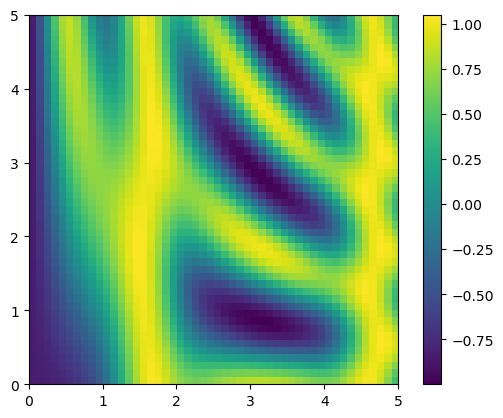

In [42]:
plt.imshow(z, origin='lower', extent=[0, 5, 0, 5],
           cmap='viridis')
plt.colorbar();

In [43]:
# x and y have 50 steps from 0 to 5
x = np.linspace(0, 5, 100)
y = np.linspace(0, 5, 100)[:, np.newaxis]

z = np.sin(x) + np.cos(y) + np.sin(x*y) + np.cos(x*y) + np.sin(x**2) + np.cos(y**2)

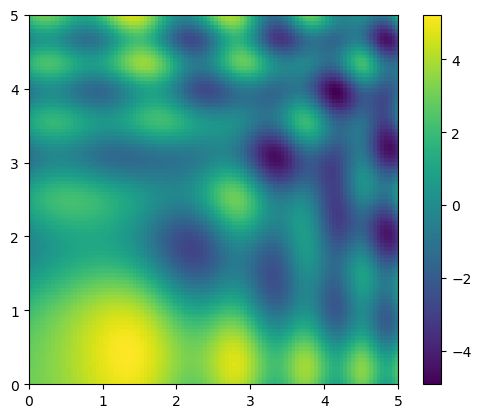

In [44]:
plt.imshow(z, origin='lower', extent=[0, 5, 0, 5],
           cmap='viridis')
plt.colorbar();

The result is a compelling visualization of the two-dimensional function.

<!--NAVIGATION-->
< [Aggregations: Min, Max, and Everything In Between](02.04-Computation-on-arrays-aggregates.ipynb) | [Contents](Index.ipynb) | [Comparisons, Masks, and Boolean Logic](02.06-Boolean-Arrays-and-Masks.ipynb) >